# Metrics / Métricas / Mètriques

**This notebook evaluates the system's overall performance, considering its classification capacity regardless of the specific optimization of the semantic pairs used in the zero-shot model.**  
**In a real application, it'd be necessary to evaluate and adjust the combination of labels to find the optimal configuration that maximizes accuracy while maintaining an appropriate analysis time.**  

*En este notebook se evalúa el rendimiento global del sistema, considerando su capacidad de clasificación independientemente de la optimización específica de las parejas semánticas utilizadas en el modelo zero-shot.*  
*En una aplicación real, sería necesario evaluar y ajustar la combinación de etiquetas para encontrar la configuración óptima que maximice la precisión manteniendo un tiempo de análisis adecuado.*  

*En aquest notebook s'avalua el rendiment global del sistema, considerant la seva capacitat de classificació independentment de l'optimització específica de les parelles semàntiques utilitzades al model zero-shot.*  
*A una aplicació real, seria necessari avaluar i ajustar la combinació d'etiquetes per trobar la configuració òptima que maximitzi la precissió mantenint un temps d'anàlisi adequat.*

>**It should be noted that running this notebook involves processing large volumes of data through the language model. Therefore, it is recommended to install a PyTorch version optimized for the available hardware, especially with GPU acceleration support when possible, as execution time may otherwise increase considerably.**
>
>*Debe tenerse en cuenta que la ejecución de este notebook implica el procesamiento de grandes volúmenes de datos mediante el modelo de lenguaje. Por este motivo, se recomienda instalar una versión de PyTorch optimizada para el hardware disponible, especialmente con soporte para aceleración mediante GPU cuando sea posible, ya que, en caso contrario, el tiempo de ejecución puede incrementarse considerablemente.*  
>
>*Cal tenir en compte que l'execució d'aquest notebook implica el processament de grans volums de dades mitjançant el model de llenguatge. Per aquest motiu, es recomana instal·lar una versió de PyTorch optimitzada per al maquinari disponible, especialment amb suport per a acceleració GPU quan sigui possible, ja que en cas contrari el temps d'execució pot augmentar considerablement.*

## Preliminary preparations / Preparaciones preliminares / Preparacions preliminars

**As a preliminary step, the libraries are loaded and two functions are prepared to make repeated calls, one to make the server calls with the necessary parameters and the second to generate the relevant metrics reports.**  

*Como paso previo, se realiza la carga de librerías y se preparan dos funciones para realizar las llamadas reiteradamente, una para hacer las llamadas al servidor con los parámetros necesarios y la segunda para realizar los informes de métricas pertinentes.*  

*Com a pas previ, es fa la càrrega de llibreries i es preparen dues funcions per fer les crides reiteradament, una per fer les crides al servidor amb els paràmetres que calguin i la segona per realitzar el informes de mètriques pertinents.*

In [1]:
# en: to load files and send requests
# es: para cargar archivos y enviar solicitudes
# ca: per carregar fitxers i enviar sol·licituds
import os
# en: I import both IO buffers to avoid future problems.
# es: Importo ambos IO buffers para evitar futuros problemas.
# ca: Importo ambdós IO buffers per evitar problemes en el futur
from io import StringIO, BytesIO
import requests

# en: to call the FastAPI server
# es: para llamar al servidor FastAPI
# ca: per cridar el servidor FastAPI
laUrl= "http://127.0.0.1:8000/"

import pandas as pd
from IPython.display import display, HTML

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def genera_metriques(titol:str, dades:pd.DataFrame,reals:str, predits:str):

    display(HTML(f"<h2>{titol}</h2>" \
        + f'<font size="4">Data sample / Muestra de los datos / Mostra de les dades</font>'))
    display(dades.head(10))
    # en: Confusion matrix
    # es: Matriz de confusión
    # ca: Matriu de confusió
    dfcm = confusion_matrix(dades[reals], dades[predits])
    sns.heatmap(dfcm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['False', 'True'], 
                yticklabels=['False', 'True'])
    plt.xlabel('Predicted ('+predits+')')
    plt.ylabel('Real ('+reals+')')
    plt.title('Confusion Matrix - '+titol)
    plt.show()

    # en: Classification metrics
    # es: Métricas de clasificación
    # ca: Mètriques de classificació

    dfcr = pd.DataFrame(classification_report(dades[reals], dades[predits], output_dict=True)).transpose()
    # en: Fix the Accuracy row
    # es: Arreglamos la fila de l'Accuracy
    # ca: Arreglem la fila de l'Accuracy

    dfcr.loc["accuracy", ["precision", "recall"]] = None
    dfcr.at["accuracy", "support"] = dades[reals].count()
    dfcr["support"] = dfcr["support"].astype(int)
    
    # en: I give a customized style to the metrics report
    # es: Le doy un estilo personalizado al informe de métricas
    # ca: Li dono un estil personalitzat a l'informe de mètriques

    display(HTML("<font size=4>Classification Report / Informe de clasificación / Informe de classificació</font>"))

    CAPCELERA = '#8cc0ff'
    BLAU_BANDES_ALTERNES = '#d0e1f9'
    LINIA_SOTA = '#000000'


    dfcr_styled = dfcr.style
    dfcr_styled.format({
        "precision": lambda x: f"{x:.3f}" if pd.notna(x) else "",
        "recall": lambda x: f"{x:.3f}" if pd.notna(x) else "",
        "f1-score": lambda x: f"{x:.3f}" if pd.notna(x) else "",
        "support": lambda x: f"{int(x)}" if pd.notna(x) else ""
    }).set_table_styles([
        {
            'selector': '', 
            'props': [
                ('font-size', '18px'), 
                ('font-family', 'sans-serif'),
                ('color', '#000000'),
                ('border-collapse', 'collapse') 
            ]
        },
        {
            'selector': 'th.col_heading, th.blank',
            'props': [('background-color', CAPCELERA), ('border-bottom', f'2px solid {LINIA_SOTA}')]
        },

        {
            'selector': 'tr:nth-child(even) td, tr:nth-child(even) th:not(.col_heading):not(.blank)', 
            'props': [('background-color', BLAU_BANDES_ALTERNES)]
        },
        {
            'selector': 'tr:nth-child(odd) td, tr:nth-child(odd) th:not(.col_heading):not(.blank)', 
            'props': [('background-color', '#ffffff')]
        },

        {'selector': 'th:not(.col_heading)', 'props': [('font-weight', 'bold')]},
        {'selector': 'td, th', 'props': [('padding', '10px 20px')]}
    ], overwrite=False)

    display(dfcr_styled)
    
    # en: ROC Curve
    # es: Curva ROC
    # ca: Corba ROC

    fpr, tpr, thresholds = roc_curve(dades[reals], dades.score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve / Curva ROC /Corba ROC- Flagged Only')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


In [3]:
def avalua_fitxer(elFitxer,**opcions_addicionals)->pd.DataFrame:
    if os.path.exists(elFitxer):
        with open(elFitxer, "rb") as f:
            fitxer = {"fitxer": (elFitxer, f)}
            resposta = requests.post(laUrl+"totDeCop/", files=fitxer, data=opcions_addicionals, headers={"tokenId": "x001b3"})
        if resposta.ok:
            verificat = pd.read_csv(BytesIO(resposta.content))
        else:
            raise Exception(f"Error: {resposta.status_code}")
    else:
        raise Exception(f"File not found /No se encuentra el fichero / Fitxer no trFbat: {elfitxer}")
    return verificat
    

## Testing by default / Testeando por defecto / Testejant per defecte

**I will run the first test with the first 3,000 records obtained from the Kaggle dataset sourced from [Prajwal Krishna's](https://github.com/praj2408/Jigsaw-Toxic-Comment-Classification) repository. I've considered them toxic if any of the columns `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, or `identity_hate` was 1 (compiled in the `any_toxic` column). We'll use the default parameters _(the default base list and the 0.65 threshold)_ and we'll only send the data file to evaluate the results. Attention: it should be keep in mind that it's an unbalanced dataset, and also that processing time is very long depending on the hardware.**  

*La primera prueba la realizaré con los 3000 primeros registros obtenidos del dataset de Kaggle obtenido del repositorio de [Prajwal Krishna](https://github.com/praj2408/Jigsaw-Toxic-Comment-Classification). He considerado que eran tóxicas si alguna de las columnas `toxic`,`severe_toxic`,`obscene`,`threat`,`insult`,`identity_hate` era 1 (recopilado en la columna `any_toxic`). Utilizaremos los parámetros por defecto *(la lista base predeterminada y el threshold de 0.65)*, solo enviaremos el archivo de datos, para evaluar los resultados. Atención: se debe tener en cuenta que es un conjunto de datos no balanceado y también que el tiempo de proceso es muy largo dependiendo del hardware.*  

*La primera prova la realitzaré amb els 3000 primers registres obtinguts del dataset de Kaggle obtingut del repositori de [Prajwal Krishna](https://github.com/praj2408/Jigsaw-Toxic-Comment-Classification). He considerat que eren tòxiques si alguna de les columnes `toxic`,`severe_toxic`,`obscene`,`threat`,`insult`,`identity_hate` era 1 (recopilat a la columna `any_toxic`).  Utilitzarem els paràmetres per defecte *(la llista base predeterminada i el threshold de 0.65)*, sols enviarem el fitxer de dades, per avaluar els resultats. Atenció: s'ha de tenir en compte que és un conjunt de dades no balancejades i també que el temps de procés és molt llarg depenet del maquinari.*

,comment_text,any_toxic,id,score,is_flagged
0,Explanation\nWhy the edits made under my usern...,False,0000997932d777bf,0.48,False
1,D'aww! He matches this background colour I'm s...,False,000103f0d9cfb60f,0.34,False
2,"Hey man, I'm really not trying to edit war. It...",False,000113f07ec002fd,0.64,False
3,"""\nMore\nI can't make any real suggestions on ...",False,0001b41b1c6bb37e,0.40,False
4,"You, sir, are my hero. Any chance you remember...",False,0001d958c54c6e35,0.28,False
5,"""\n\nCongratulations from me as well, use the ...",False,00025465d4725e87,0.03,False
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,True,0002bcb3da6cb337,0.97,True
7,Your vandalism to the Matt Shirvington article...,False,00031b1e95af7921,0.83,True
8,Sorry if the word 'nonsense' was offensive to ...,False,00037261f536c51d,0.82,True
9,alignment on this subject and which are contra...,False,00040093b2687caa,0.69,True


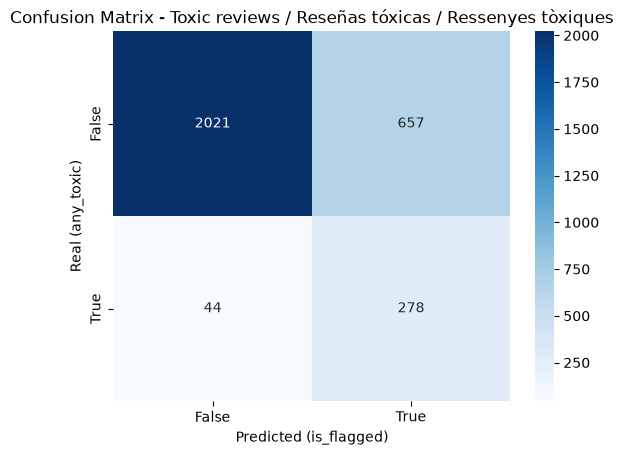

,precision,recall,f1-score,support
False,0.979,0.755,0.852,2678
True,0.297,0.863,0.442,322
accuracy,,,0.766,3000
macro avg,0.638,0.809,0.647,3000
weighted avg,0.906,0.766,0.808,3000


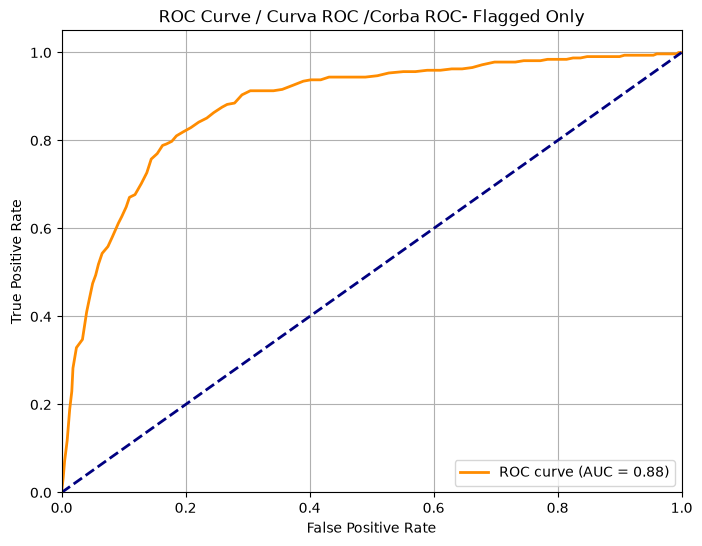

In [4]:
dataset = avalua_fitxer("data/en_3000.csv")
genera_metriques("Toxic reviews / Reseñas tóxicas / Ressenyes tòxiques",dataset, "any_toxic", "is_flagged")

### Model evaluation and conclusions / Conclusiones de la evaluación / Conclusions de l'avaluació

The classification model achieved an overall accuracy of 0.766 and a ROC AUC value of 0.88, indicating a good discriminative capability between the two classes. However, the results reveal an important imbalance in class-specific performance, which is partly influenced by the highly uneven distribution of the evaluated samples, where the positive class represents only 10.7% of the dataset.  

The model shows excellent precision for the negative class (0.979), meaning that negative predictions are highly reliable. However, the recall value for this class (0.755) indicates that some negative instances are incorrectly classified as positive. Regarding the positive class, the model achieves a high recall (0.863), demonstrating a strong ability to identify most toxic cases. Nevertheless, the low precision value (0.297) indicates a considerable number of false positive predictions, resulting in a lower F1-score (0.442).  

The ROC AUC value of 0.88 confirms that the model has good discriminative capacity, although the selected classification threshold produces an imbalance between precision and recall. Therefore, the model is suitable for scenarios where detecting potentially toxic content is prioritized, but further optimization would be required to improve the balance between false positives and false negatives.  

It should also be considered that the original toxicity annotations may contain a degree of subjectivity, as the perception of offensive or inappropriate language can vary depending on the context and the criteria applied during the labeling process. Consequently, some classification errors may be related not only to model limitations but also to ambiguity in the reference labels.  

Future improvements could involve optimizing the selection of label pairs used during the zero-shot classification process, as different semantic formulations may influence the model's interpretation of toxicity. Additionally, adjusting the decision threshold could help achieve a more suitable trade-off between precision and recall according to the specific requirements of the application.  

---

El modelo de clasificación obtuvo una exactitud global (accuracy) de 0,766 y un valor ROC AUC de 0,88, lo que indica una buena capacidad de discriminación entre ambas clases. Sin embargo, los resultados muestran un desequilibrio importante en el rendimiento por clase, condicionado en parte por la distribución desigual de las muestras evaluadas, donde la clase positiva representa únicamente el 10,7% del conjunto de datos.  

El modelo presenta una precisión excelente para la clase negativa (0,979), indicando que las predicciones negativas son altamente fiables. No obstante, el valor de recall para esta clase (0,755) muestra que algunos casos negativos son clasificados incorrectamente como positivos. En cuanto a la clase positiva, el modelo alcanza un recall elevado (0,863), demostrando una buena capacidad para identificar la mayoría de los casos tóxicos. Sin embargo, la baja precisión obtenida (0,297) indica la existencia de un número considerable de falsos positivos, lo que se refleja en un valor F1 reducido (0,442).  

El valor ROC AUC de 0,88 confirma que el modelo dispone de una buena capacidad discriminativa, aunque el umbral de clasificación seleccionado genera un desequilibrio entre precisión y sensibilidad. Por este motivo, el modelo resulta adecuado en escenarios donde la detección de contenido potencialmente tóxico sea prioritaria, pero sería necesario realizar una optimización adicional para conseguir un mejor equilibrio entre falsos positivos y falsos negativos.  

También debe tenerse en cuenta que las anotaciones originales de toxicidad pueden contener cierto grado de subjetividad, ya que la percepción de lenguaje ofensivo o inapropiado puede variar en función del contexto y de los criterios utilizados durante el proceso de etiquetado. En consecuencia, algunos errores de clasificación pueden estar relacionados no únicamente con las limitaciones del modelo, sino también con cierta ambigüedad presente en las etiquetas de referencia.  

Como líneas de mejora futura, sería recomendable optimizar la selección de los pares de etiquetas utilizados en el proceso de clasificación zero-shot, ya que diferentes formulaciones semánticas pueden modificar la interpretación realizada por el modelo. Asimismo, el ajuste del umbral de decisión permitiría encontrar un equilibrio más adecuado entre precisión y recall en función de los objetivos específicos de la aplicación.  

---

El model de classificació va obtenir una exactitud global (accuracy) de 0,766 i un valor ROC AUC de 0,88, fet que indica una bona capacitat de discriminació entre les dues classes. Tanmateix, els resultats mostren un desequilibri important en el rendiment per classe, condicionat en part per la distribució desigual de les mostres avaluades, on la classe positiva representa únicament el 10,7% del conjunt de dades.  

El model presenta una precisió excel·lent per a la classe negativa (0,979), indicant que les prediccions negatives són altament fiables. No obstant això, el valor de recall d’aquesta classe (0,755) mostra que alguns casos negatius són classificats incorrectament com a positius. Pel que fa a la classe positiva, el model assoleix un recall elevat (0,863), demostrant una bona capacitat per identificar la majoria dels casos tòxics. Tot i això, la baixa precisió obtinguda (0,297) indica l’existència d’un nombre considerable de falsos positius, fet que es reflecteix en un valor F1 més reduït (0,442).  

El valor ROC AUC de 0,88 confirma que el model disposa d’una bona capacitat discriminativa, encara que el llindar de classificació seleccionat genera un desequilibri entre precisió i sensibilitat. Per aquest motiu, el model és adequat en escenaris on la detecció de contingut potencialment tòxic sigui prioritària, però seria necessari realitzar una optimització addicional per aconseguir un millor equilibri entre falsos positius i falsos negatius.  

També cal tenir en compte que les anotacions originals de toxicitat poden contenir un cert grau de subjectivitat, ja que la percepció del llenguatge ofensiu o inadequat pot variar segons el context i els criteris aplicats durant el procés d’etiquetatge. En conseqüència, alguns errors de classificació poden estar relacionats no només amb les limitacions del model, sinó també amb una certa ambigüitat present en les etiquetes de referència.  

Com a línies de millora futura, seria recomanable optimitzar la selecció dels parells d’etiquetes utilitzats durant el procés de classificació zero-shot, ja que diferents formulacions semàntiques poden influir en la interpretació de la toxicitat per part del model. Igualment, l’ajust del llindar de decisió permetria obtenir un equilibri més adequat entre precisió i recall en funció dels objectius específics de l’aplicació.  

---


**...And what'd happen if we tell the model to use a threshold of 0.75? How does it affect the results?**  
*...¿Y qué pasaría si le decimos al modelo que utilice un umbral de 0.75? ¿En qué afecta a los resultados?*  
*...I què passaria si li diem al model que utilitzi un llindar de 0.75? en què afecta als resultats?*  

,comment_text,any_toxic,id,score,is_flagged
0,Explanation\nWhy the edits made under my usern...,False,0000997932d777bf,0.48,False
1,D'aww! He matches this background colour I'm s...,False,000103f0d9cfb60f,0.34,False
2,"Hey man, I'm really not trying to edit war. It...",False,000113f07ec002fd,0.64,False
3,"""\nMore\nI can't make any real suggestions on ...",False,0001b41b1c6bb37e,0.40,False
4,"You, sir, are my hero. Any chance you remember...",False,0001d958c54c6e35,0.28,False
5,"""\n\nCongratulations from me as well, use the ...",False,00025465d4725e87,0.03,False
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,True,0002bcb3da6cb337,0.97,True
7,Your vandalism to the Matt Shirvington article...,False,00031b1e95af7921,0.83,True
8,Sorry if the word 'nonsense' was offensive to ...,False,00037261f536c51d,0.82,True
9,alignment on this subject and which are contra...,False,00040093b2687caa,0.69,False


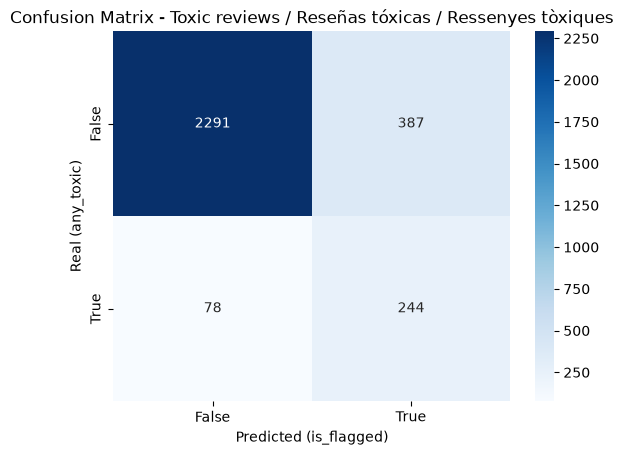

,precision,recall,f1-score,support
False,0.967,0.855,0.908,2678
True,0.387,0.758,0.512,322
accuracy,,,0.845,3000
macro avg,0.677,0.807,0.710,3000
weighted avg,0.905,0.845,0.865,3000


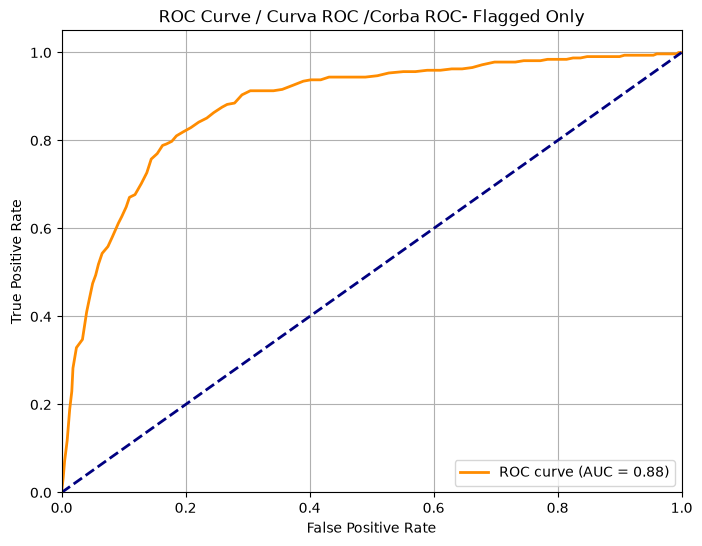

In [5]:
dataset = avalua_fitxer("data/en_3000.csv",thershold=0.75)
genera_metriques("Toxic reviews / Reseñas tóxicas / Ressenyes tòxiques",dataset, "any_toxic", "is_flagged")

#### Threshold Optimization Experiment and Findings / Experimentación y conclusiones sobre el umbral de decisión / Experimentació i conclusions sobre el llindar de decisió

**Adjusting the classification threshold to 0.75 improves the overall model performance, increasing accuracy from 0.766 to 0.845. The main effect is a reduction in false positive predictions, reflected by the increase in positive-class precision from 0.297 to 0.387. Although the recall for the positive class decreases from 0.863 to 0.758, the model achieves a better balance between precision and recall, resulting in an improved F1-score (from 0.442 to 0.512). Overall, this threshold adjustment provides a more balanced classification behaviour while maintaining a good ability to detect toxic cases.**  

*El ajuste del umbral de clasificación a 0,75 mejora el rendimiento global del modelo, incrementando la exactitud de 0,766 a 0,845. El principal efecto observado es una reducción de las predicciones positivas incorrectas, reflejada en el aumento de la precisión de la clase positiva de 0,297 a 0,387. Aunque el recall de la clase positiva disminuye de 0,863 a 0,758, el modelo consigue un mejor equilibrio entre precisión y sensibilidad, aumentando el valor F1 de 0,442 a 0,512. En conjunto, este ajuste proporciona un comportamiento de clasificación más equilibrado manteniendo una buena capacidad para detectar casos tóxicos.*  

*L’ajust del llindar de classificació a 0,75 millora el rendiment global del model, incrementant l’exactitud de 0,766 a 0,845. El principal efecte observat és una reducció de les prediccions positives incorrectes, reflectida en l’augment de la precisió de la classe positiva de 0,297 a 0,387. Tot i que el recall de la classe positiva disminueix de 0,863 a 0,758, el model aconsegueix un millor equilibri entre precisió i sensibilitat, augmentant el valor F1 de 0,442 a 0,512. En conjunt, aquest ajust proporciona un comportament de classificació més equilibrat mantenint una bona capacitat per detectar casos tòxics.*  

---  

<br>

## Second test, different topic with customized list and thresholds / Segundo test, temática diferente con lista y umbrales personalizados / Segon test, temàtica diferent amb llista i llindars customitzats
**Now, we'll test by sending a `dummy` file of 200 reviews that we've generated by crossing subjects and predicates to get reviews related or not to restaurants. Some sentences don't make much sense, but they'll help us check if the model works well.**  
*Ahora, hacemos la prueba enviando un fichero `dummy` de 200 reseñas que hemos generado cruzando sujetos y predicados para obtener reseñas relacionadas o no con restaurantes. Algunas frases no tienen mucho sentido, pero nos servirán para comprobar si el modelo funciona bien.*  
*Ara, fem la prova enviant un fitxer `dummy` de 200 ressenyes que hem generat creuant subjectes i predicats per obtenir ressenyes relacionades o no amb restaurants. Algunes frases no tenen gaire sentit, però ens serviran per comprovar si el model funciona bé.*

**In this case, since the topic we want to evaluate changes, I'll pass a list with 2 pairs of elements so it evaluates whether they correspond to restaurants or not. I'll also pass a threshold coefficient of 0.7 so everything above this value's considered a restaurant.**  
*En este caso, como el tema que queremos evaluar cambia, pasaré una lista con 2 parejas de elementos para que evalúe si corresponden a restaurantes o no. También pasaré un coeficiente de corte de 0.7 para que todo lo que esté por encima de este valor sea considerado como restaurante.*  
*En aquest cas, com el tema que volem avaluar canvia, passaré una llista amb 2 parelles d'elements perquè avalui si corresponen a restaurants o no. També passaré un coeficient de tall de 0.7 perquè tot allò que estigui per sobre d'aquest valor sigui considerat com a restaurant.*

,review,restaurant,score,is_flagged
0,The wait staff was terrible. A delightful surp...,True,0.60,False
1,The chef was mediocre. Waste of money.,True,0.83,True
2,The battery is interesting. Do not watch.,False,0.36,False
3,This restaurant looked perfect. Highly recomme...,True,0.99,True
4,Our experience ended up being amazing. I would...,True,0.67,False
5,The plot felt slow. Loved every minute.,False,0.45,False
6,Our experience felt delicious. Not worth the h...,True,0.88,True
7,The wait staff looked perfect. Highly recommen...,True,0.82,True
8,The menu tasted excellent. A delightful surprise.,True,0.99,True
9,The ambiance was bland. Never going back.,True,0.34,False


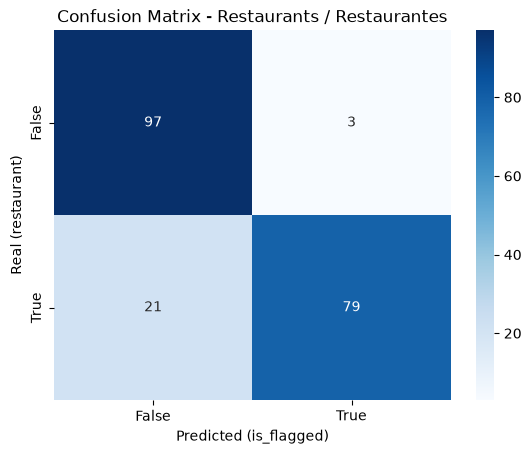

,precision,recall,f1-score,support
False,0.822,0.970,0.890,100
True,0.963,0.790,0.868,100
accuracy,,,0.880,200
macro avg,0.893,0.880,0.879,200
weighted avg,0.893,0.880,0.879,200


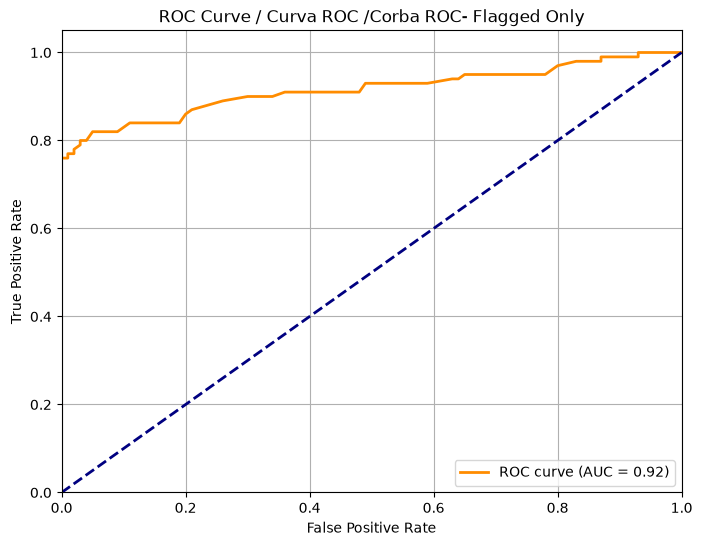

In [6]:
llista_rest = [("It's related to restaurant", "Is not related to restaurant"),
("It's related to food", "Is not related to food")]
dataset = avalua_fitxer("data/rev_restaurants.csv",laLlista=str(llista_rest),thershold=0.7)
genera_metriques("Restaurants / Restaurantes",dataset, "restaurant", "is_flagged")

### Model evaluation and conclusions / Conclusiones de la evaluación / Conclusions de l'avaluació

The classification model achieved an overall accuracy of 0.88 and a ROC AUC score of 0.915, indicating strong predictive performance and excellent discriminative capability between the two classes. The balanced class distribution further supports the reliability of these metrics.

Class-specific results reveal a slight asymmetry in performance. The negative class achieved a high recall of 0.97, indicating that most negative instances were correctly identified. Conversely, the positive class obtained a precision of 0.96, suggesting that predictions labeled as positive were highly reliable. However, the recall for the positive class was lower (0.79), indicating that some positive instances remained undetected.

The F1-scores of 0.89 and 0.87 for the negative and positive classes, respectively, demonstrate a well-balanced trade-off between precision and recall. Overall, the results suggest that the model provides robust classification performance while maintaining excellent class separability, as reflected by the ROC AUC value above 0.9.

---

El modelo de clasificación alcanzó una exactitud global (accuracy) de 0.88 y un valor ROC AUC de 0.915, lo que indica un rendimiento predictivo sólido y una excelente capacidad para discriminar entre ambas clases. La distribución equilibrada de las clases refuerza además la fiabilidad de estas métricas.

El análisis por clase muestra una ligera asimetría en el comportamiento del modelo. La clase negativa obtuvo una sensibilidad (recall) de 0.97, lo que indica que la mayoría de los casos negativos fueron identificados correctamente. Por su parte, la clase positiva alcanzó una precisión de 0.96, evidenciando que las predicciones positivas realizadas por el modelo son altamente fiables. Sin embargo, el recall de la clase positiva fue inferior (0.79), lo que sugiere que una parte de los casos positivos no fue detectada.

Las puntuaciones F1 de 0.89 y 0.87 para las clases negativa y positiva, respectivamente, reflejan un equilibrio adecuado entre precisión y sensibilidad. En conjunto, los resultados indican que el modelo presenta un rendimiento robusto y una excelente capacidad de separación entre clases, respaldada por un valor ROC AUC superior a 0.9.

---

El model de classificació va assolir una exactitud global (accuracy) de 0,88 i un valor ROC AUC de 0,915, fet que indica un rendiment predictiu sòlid i una excel·lent capacitat de discriminació entre les dues classes. La distribució equilibrada de les mostres entre classes reforça la fiabilitat d'aquestes mètriques.

L'anàlisi per classe mostra una lleugera asimetria en el comportament del model. La classe negativa va obtenir un recall de 0,97, la qual cosa indica que la majoria dels casos negatius van ser identificats correctament. En canvi, la classe positiva va assolir una precisió de 0,96, fet que evidencia que les prediccions positives realitzades pel model són altament fiables. Tanmateix, el recall de la classe positiva va ser inferior (0,79), cosa que suggereix que alguns casos positius no van ser detectats.

Els valors F1 de 0,89 i 0,87 per a les classes negativa i positiva, respectivament, reflecteixen un bon equilibri entre precisió i sensibilitat. En conjunt, els resultats indiquen que el model presenta un rendiment robust i una excel·lent capacitat de separació entre classes, recolzada per un valor ROC AUC superior a 0,9.

---  

<br>



## Feasibility and Potential of the Proposed Approach / Viabilidad y potencial de la propuesta / Viabilitat i potencial de la proposta

**The results obtained suggest that the proposed solution has a high discriminative capability. Although the performance significantly depends on the selection of label pairs and the decision threshold used, the experiments conducted demonstrate that an appropriate configuration of these parameters can provide highly satisfactory levels of precision and detection capability. These findings confirm the feasibility of the application for practical use.**  

*Los resultados obtenidos sugieren que la solución propuesta posee una capacidad discriminativa elevada. Aunque el rendimiento depende significativamente de la selección de los pares de etiquetas y del umbral de decisión empleado, los experimentos realizados muestran que una configuración adecuada de estos parámetros puede proporcionar niveles de precisión y capacidad de detección muy satisfactorios, confirmando la viabilidad de la aplicación para su uso práctico.*  

*Els resultats obtinguts suggereixen que la solució proposada presenta una elevada capacitat discriminativa. Tot i que el rendiment depèn significativament de la selecció dels parells d’etiquetes i del llindar de decisió utilitzat, els experiments realitzats mostren que una configuració adequada d’aquests paràmetres pot proporcionar nivells de precisió i capacitat de detecció molt satisfactoris. Aquests resultats confirmen la viabilitat de l’aplicació per a un ús pràctic.*